In [82]:
import cv2
import numpy as np
from show_img import show_img

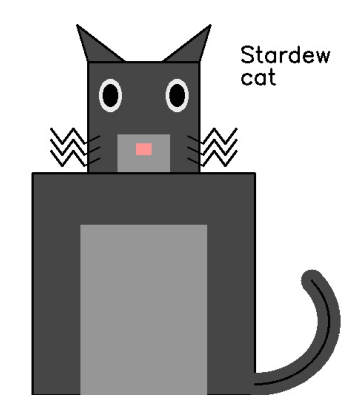

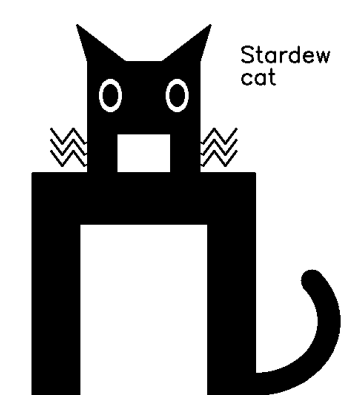

In [83]:
img = cv2.imread("my_cat.jpg")
show_img(img, size=5)
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, img_thres = cv2.threshold(img_grayscale, 127, 255, cv2.THRESH_BINARY)
show_img(img_thres, size=5)

## Выделение контуров фигур

In [126]:
def show_perim_and_square(cnt):
   perim = cv2.arcLength(cnt, True)
   sqr = cv2.moments(cnt)['m00'] # получаем площадь из момента 00
   print(f"perimeter is {perim:.2f}, "
         f"square is {sqr:.2f}")

perimeter is 798.00, square is 38930.00
total rect count: 3


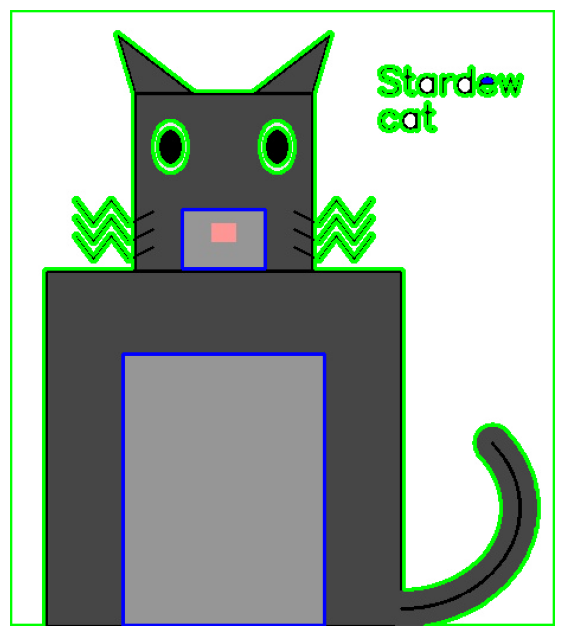

In [130]:
blue, green, red = (255, 0, 0), (0, 255, 0), (0, 0, 255)
contours, _ = cv2.findContours(img_thres, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

rect_num = 1 # номер прямоугольника для вычислений

rect_cnt = 0
img_con = img.copy()
for contour in contours:
    epsilon = 0.01 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    vertices = len(approx)

    if vertices == 4:
        cv2.drawContours(img_con, [contour], 0, blue, 2)
        rect_cnt += 1
        if rect_num == rect_cnt: show_perim_and_square(contour)
    elif vertices > 8:
        cv2.drawContours(img_con, [contour], 0, green, 2)
print(f"total rect count: {rect_cnt}")

show_img(img_con, size = 8)
